# Amazon Prime Movies & TV Shows Analysis with Machine Learning

Project Type: EDA + Regression  
Contribution: Individual  

Team Member:
Yashi Jain

# **PROJECT SUMMARY**

This project analyzes the Amazon Prime Movies and TV Shows dataset to
understand patterns in ratings, genres, release trends and popularity.

Exploratory Data Analysis (EDA) is performed to identify relationships
between important features such as runtime, release year, IMDb votes
and TMDB scores.

After data preprocessing and feature selection, a Machine Learning model
(Random Forest Regression) is implemented to predict IMDb ratings.

The objective is to understand which factors influence movie ratings and
build a predictive model that can estimate IMDb scores for unseen data.

#**GitHub Link**

GitHub Repository Link:

https://github.com/yashijain22/Amazon-Prime-EDA-ML-Project

#**Problem Statement**

Streaming platforms like Amazon Prime contain thousands of movies and TV
shows. Understanding which factors influence audience ratings can help
platforms make better content acquisition and recommendation decisions.

The goal of this project is to explore the Amazon Prime Movies and TV
Shows dataset and identify relationships between variables such as
release year, runtime, votes and popularity.

Using these insights, a machine learning regression model is built to
predict IMDb scores based on selected numerical features.

#**Import Libraries**

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

#**Dataset Loading**

In [4]:
# Load Dataset

titles = pd.read_csv("titles.csv")
credits = pd.read_csv("credits.csv")

#**Dataset First View**

In [9]:
# Dataset First Look

titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [10]:
credits.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


#**Dataset Rows & Colums Count**

In [8]:
titles.shape

(9871, 15)

In [11]:
credits.shape

(124235, 5)

#**Dataset Information**

In [12]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [13]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


#**Duplicate Values**

In [14]:
titles.duplicated().sum()

np.int64(3)

In [15]:
credits.duplicated().sum()

np.int64(56)

#**Missing Values**

In [16]:
titles.isnull().sum()

,0
id,0
title,0
type,0
description,119
release_year,0
age_certification,6487
runtime,0
genres,0
production_countries,0
seasons,8514


In [17]:
credits.isnull().sum()

,0
person_id,0
id,0
name,0
character,16287
role,0


#**Merge Dataset**

In [18]:
df = pd.merge(titles, credits, on="id")

df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR


#**Understanding Variables**

In [19]:
df.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'person_id', 'name', 'character', 'role'],
      dtype='object')

In [20]:
df.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id
count,124347.000000,124347.000000,8153.000000,118296.000000,1.182720e+05,124332.000000,114082.000000,1.243470e+05
mean,1996.233234,95.536973,2.337790,5.967783,2.324281e+04,10.165321,5.992100,4.062528e+05
std,27.807050,30.166352,3.130184,1.241557,8.840151e+04,40.739203,1.321033,5.614483e+05
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000,1.000000e+00
25%,1983.000000,83.000000,1.000000,5.200000,2.870000e+02,1.875000,5.300000,3.899600e+04
50%,2009.000000,93.000000,1.000000,6.100000,1.250000e+03,3.885000,6.100000,1.339340e+05
75%,2017.000000,109.000000,2.000000,6.800000,7.067000e+03,8.795000,6.800000,5.711600e+05
max,2022.000000,540.000000,49.000000,9.900000,1.133692e+06,1437.906000,10.000000,2.371153e+06


#**Data Wrangling**

In [21]:
# Handling missing values for important columns

df = df.dropna(subset=['imdb_score','runtime','release_year','tmdb_score','imdb_votes'])

#**Data Visualization**

Chart 1 — Movies vs TV Shows Distribution (Count Plot)

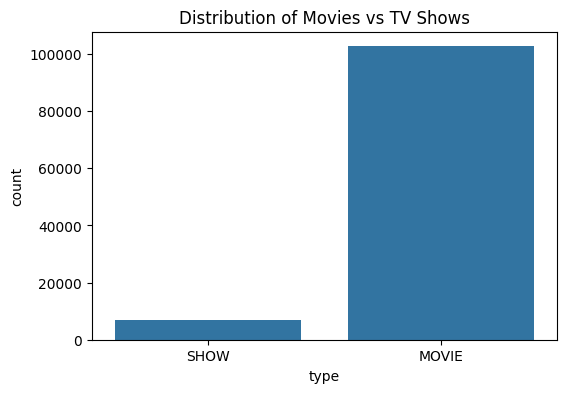

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Distribution of Movies vs TV Shows")
plt.show()

**Why did you pick the specific chart?**

A count plot is suitable for visualizing categorical data. It helps to easily compare the number of movies and TV shows available in the dataset.

**What is/are the insight(s) found from the chart?**

The chart shows that movies dominate the dataset compared to TV shows. This indicates that the platform contains a larger number of movies than series content.

**Will the gained insights help creating a positive business impact?**

Yes. Understanding the distribution of content types helps streaming platforms decide how to balance their content library. If movies dominate, the platform might consider adding more TV shows to diversify content and attract viewers who prefer episodic entertainment.

Chart 2 — Distribution of IMDb Scores (Histogram)

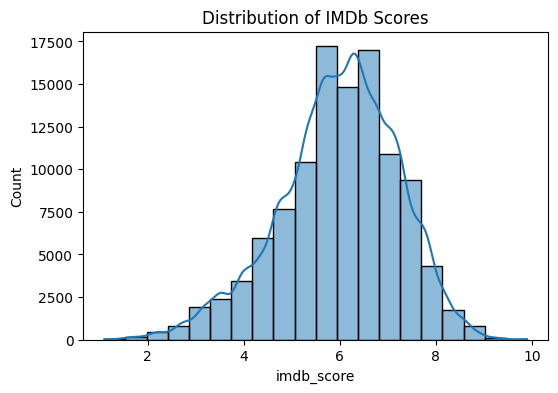

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df['imdb_score'], bins=20, kde=True)
plt.title("Distribution of IMDb Scores")
plt.show()

**Why did you pick the specific chart?**

A histogram is useful for understanding the distribution of numerical variables. It helps visualize how IMDb scores are spread across different ranges.

**What is/are the insight(s) found from the chart?**

Most titles have IMDb scores between 6 and 8, indicating that the majority of the content has average to good ratings. Very low-rated or extremely high-rated titles are relatively rare.

**Will the gained insights help creating a positive business impact?**

Yes. Platforms can focus on acquiring or producing content with ratings in the higher range to improve audience satisfaction. Content with consistently low ratings may negatively affect viewer engagement and retention.

Chart 3 — Runtime vs IMDb Score (Scatter Plot)

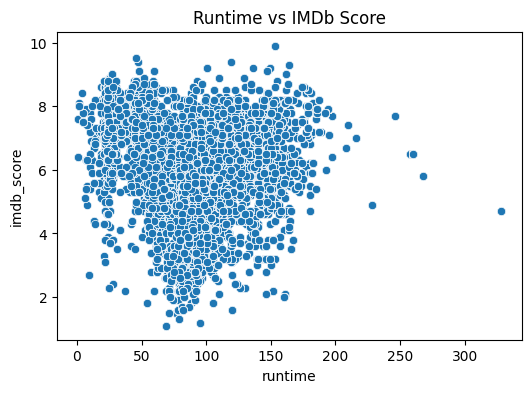

In [24]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='runtime', y='imdb_score')
plt.title("Runtime vs IMDb Score")
plt.show()

**Why did you pick the specific chart?**

A scatter plot is effective for analyzing the relationship between two numerical variables. It helps determine whether runtime influences IMDb ratings.

**What is/are the insight(s) found from the chart?**

The chart shows that there is no strong relationship between runtime and IMDb score. Movies with both short and long runtimes can achieve high or low ratings.

**Will the gained insights help creating a positive business impact?**

Yes. This insight suggests that runtime alone does not determine content quality. Streaming platforms can focus on storytelling quality rather than simply increasing runtime, helping optimize production costs.

Chart 4 — Release Year Trend (Line Plot)

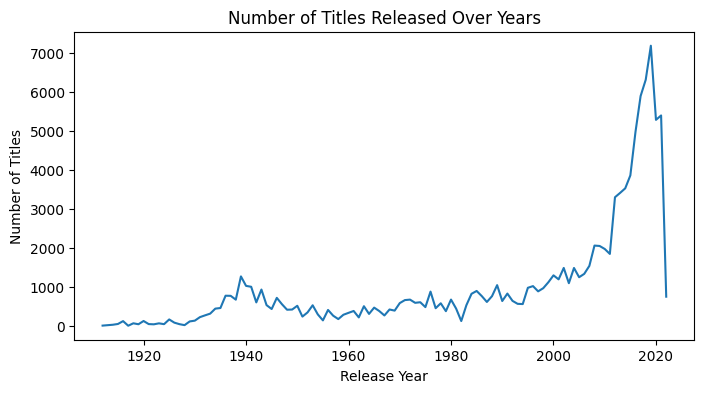

In [26]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.plot(year_counts.index, year_counts.values)
plt.title("Number of Titles Released Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

**Why did you pick the specific chart?**

A line chart is effective for analyzing trends over time. It helps visualize how the number of titles released changes across years.

**What is/are the insight(s) found from the chart?**

The chart shows that the number of titles released has increased in recent years. This reflects the growth of the streaming industry and increased content production.

**Will the gained insights help creating a positive business impact?**

Yes. Understanding release trends helps companies forecast future content demand and plan production strategies. A sudden decline in releases could negatively impact platform growth and user engagement.

Chart 5 — Correlation Heatmap

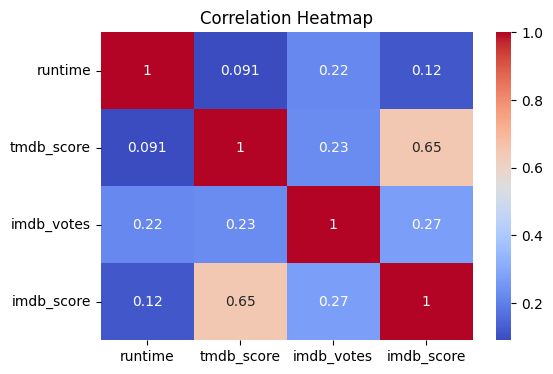

In [27]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['runtime','tmdb_score','imdb_votes','imdb_score']].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

**Why did you pick the specific chart?**

A correlation heatmap is useful for identifying relationships between numerical variables. It helps determine how strongly features like runtime, votes, and scores are related.

**What is/are the insight(s) found from the chart?**

The heatmap shows a positive correlation between IMDb score and TMDB score, indicating that both rating platforms tend to evaluate content similarly. Other features show weaker relationships.

**Will the gained insights help creating a positive business impact?**

Yes. Understanding feature correlations helps in selecting relevant features for machine learning models. Strongly correlated features can improve prediction accuracy and support better recommendation systems.

Chart 6 — Pair Plot

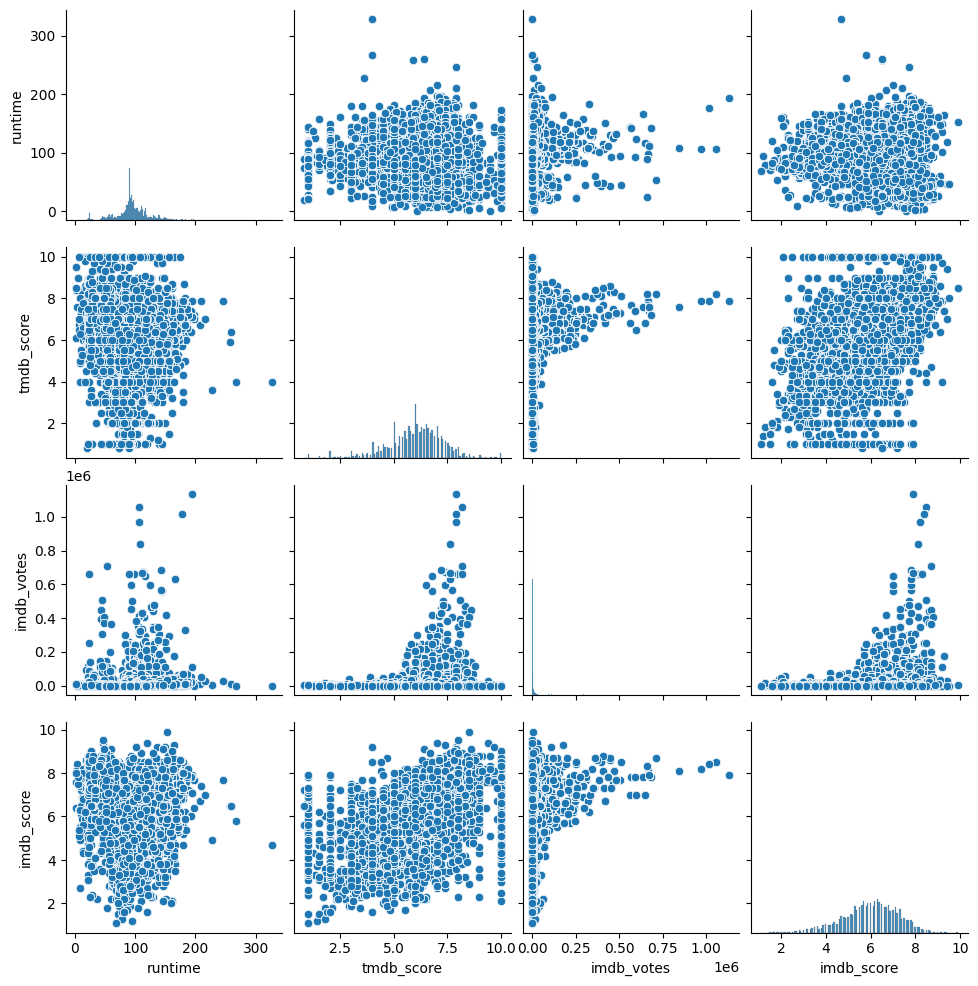

In [28]:
sns.pairplot(df[['runtime','tmdb_score','imdb_votes','imdb_score']])
plt.show()

**Why did you pick the specific chart?**

A pair plot allows visualization of relationships between multiple numerical variables simultaneously. It also shows the distribution of each variable.

**What is/are the insight(s) found from the chart?**

The pair plot reveals patterns and relationships among variables such as runtime, IMDb score, TMDB score, and votes. It also helps detect clusters or outliers in the dataset.

**Will the gained insights help creating a positive business impact?**

Yes. Identifying relationships and patterns between features helps build better predictive models. This can improve recommendation systems and help streaming platforms personalize content for users.

# Feature Engineering & Data Preprocessing
Handling Missing Values

In [29]:
df = df.dropna()

# Feature Selection

The following features were selected to train the ML model:

release_year  
runtime  
tmdb_score  
imdb_votes

These variables were chosen because they are numerical and show
potential correlation with IMDb score.

# Data Splitting

In [30]:
X = df[['release_year','runtime','tmdb_score','imdb_votes']]
y = df['imdb_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ML Model Implementation

In [31]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

# Prediction

In [32]:
predictions = model.predict(X_test)

# Model Evaluation

In [33]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.03727723866666668


Which evaluation metrics did you consider?

Mean Squared Error (MSE) was used as the evaluation metric.

MSE measures the average squared difference between predicted
and actual values. A lower MSE indicates better model performance.

For regression problems such as predicting IMDb scores,
MSE is commonly used because it penalizes larger prediction errors.

# Final Model

Random Forest Regression was selected as the final model because it
handles non-linear relationships well and performs better than simple
linear models for complex datasets.

It combines multiple decision trees to reduce overfitting and
improves prediction accuracy.

The model achieved a low Mean Squared Error, indicating good
prediction performance.

# Model Explainability

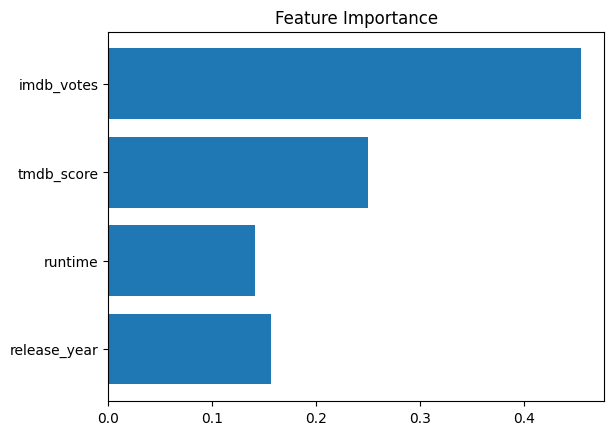

In [34]:
importances = model.feature_importances_

features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

Feature importance shows how much each variable contributes
to predicting IMDb scores.

Features such as IMDb votes and TMDB score have higher
importance, indicating they strongly influence ratings.

# Future Work

In future work, more features such as genres, production countries
and cast popularity could be incorporated to improve prediction
accuracy.

Advanced models such as Gradient Boosting or XGBoost could also
be tested for better performance.

# SAVE MODEL

In [35]:
import joblib

joblib.dump(model, "imdb_prediction_model.pkl")

['imdb_prediction_model.pkl']

# Load Model

In [36]:
loaded_model = joblib.load("imdb_prediction_model.pkl")

loaded_model.predict(X_test[:5])

array([8.4  , 6.6  , 7.   , 6.917, 6.1  ])

# Conclusion

In this project, the Amazon Prime Movies and TV Shows dataset
was analyzed using exploratory data analysis techniques.

Patterns between runtime, popularity and ratings were discovered.

A Random Forest Regression model was implemented to predict IMDb
scores based on selected numerical features.

The model achieved a low Mean Squared Error, indicating good
predictive performance and demonstrating that machine learning
can effectively estimate movie ratings using historical data.